In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46395,Workers: 16
Dashboard: http://127.0.0.1:8787/status,Total threads: 128
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:45843,Total threads: 8
Dashboard: http://127.0.0.1:41859/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:35967,


In [2]:
## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

data_dir = '/data/SO6/TPOSE/constraints/profiles/'
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/model_setup/'

ds2012 = xr.open_dataset(data_dir + 'WOD_TP_2012_GLD_w.nc')
ds2013_A = xr.open_dataset(data_dir + 'WOD_TP_2013_GLD_A_w.nc')
ds2013_B = xr.open_dataset(data_dir + 'WOD_TP_2013_GLD_B_w.nc')

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 7))
proj = ccrs.PlateCarree(central_longitude=180)
ax = plt.axes(projection=proj)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linewidth=0.2) 

ax.plot(ds2012.prof_lon,ds2012.prof_lat,'k.',label='WOD_TP_2012_GLD_w')
ax.plot(ds2013_A.prof_lon,ds2013_A.prof_lat,'r.',label='WOD_TP_2013_GLD_A_w')
ax.plot(ds2013_B.prof_lon,ds2013_B.prof_lat,'b.',label='WOD_TP_2012_GLD_B_w')
ax.legend()
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Glider Locations')
plt.tight_layout()
plt.savefig(foldername + 'glider_loc.png')

ModuleNotFoundError: No module named 'cartopy'

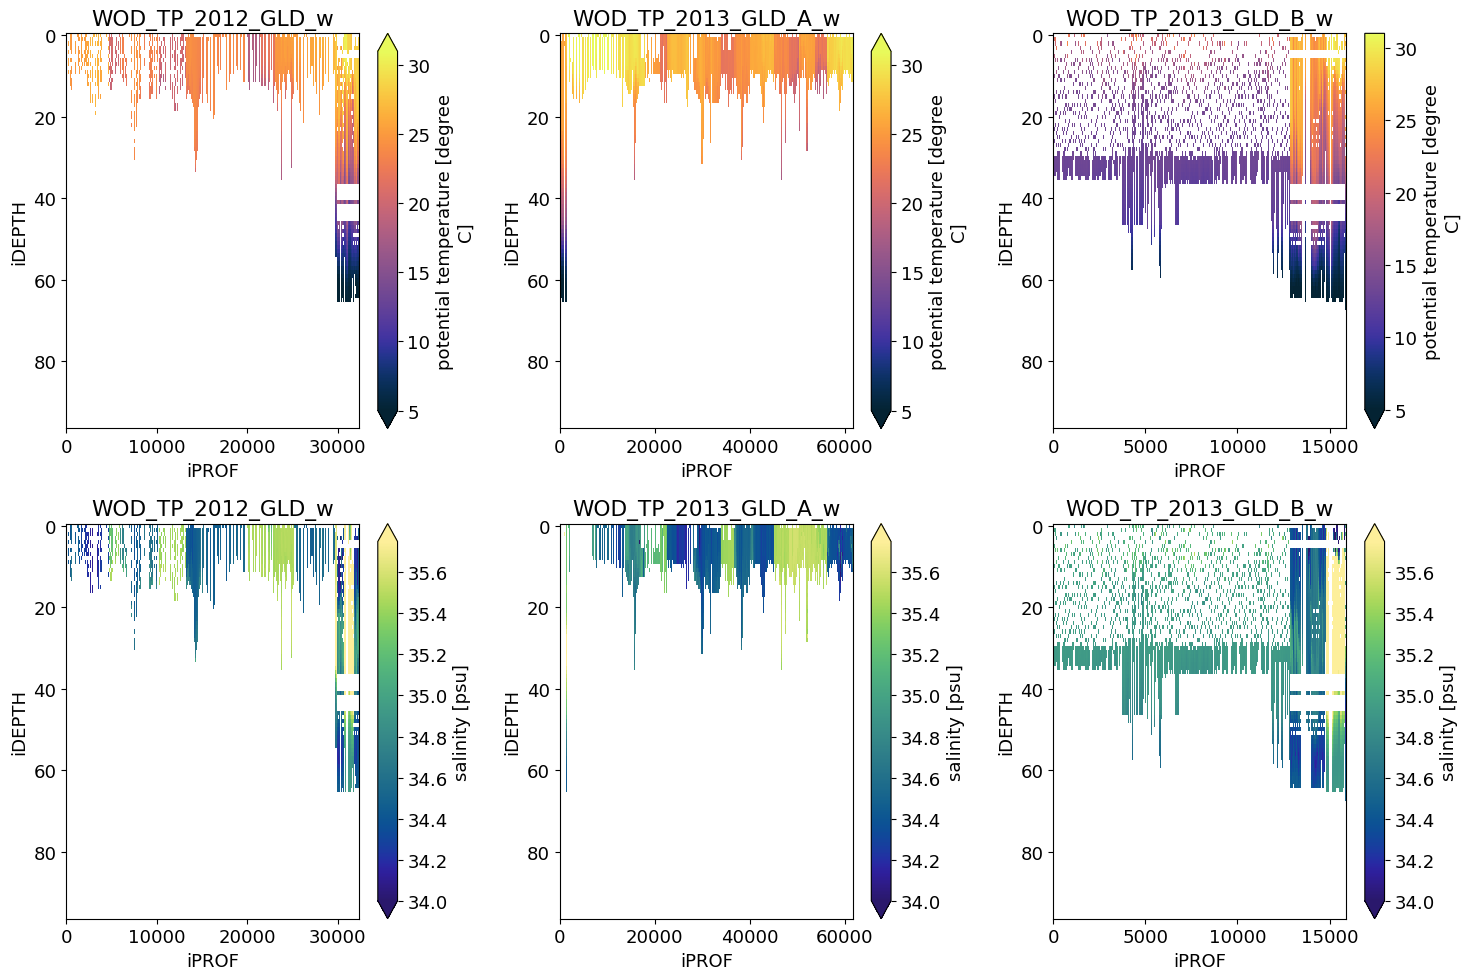

In [11]:
fig, ax = plt.subplots(figsize=(15,10),nrows=2,ncols=3)
ds2012.prof_T.plot(x='iPROF',ax=ax[0,0],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,0].invert_yaxis()
ax[0,0].set_title('WOD_TP_2012_GLD_w')
ds2013_A.prof_T.plot(x='iPROF',ax=ax[0,1],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,1].invert_yaxis()
ax[0,1].set_title('WOD_TP_2013_GLD_A_w')
ds2013_B.prof_T.plot(x='iPROF',ax=ax[0,2],vmin=5,vmax=31,cmap=cmo.thermal)
ax[0,2].invert_yaxis()
ax[0,2].set_title('WOD_TP_2013_GLD_B_w')

ds2012.prof_S.plot(x='iPROF',ax=ax[1,0],vmin=34.0,vmax=35.75,cmap=cmo.haline)
ax[1,0].invert_yaxis()
ax[1,0].set_title('WOD_TP_2012_GLD_w')
ds2013_A.prof_S.plot(x='iPROF',ax=ax[1,1],vmin=34.0,vmax=35.75,cmap=cmo.haline)
ax[1,1].invert_yaxis()
ax[1,1].set_title('WOD_TP_2013_GLD_A_w')
ds2013_B.prof_S.plot(x='iPROF',ax=ax[1,2],vmin=34.0,vmax=35.75,cmap=cmo.haline)
ax[1,2].invert_yaxis()
ax[1,2].set_title('WOD_TP_2013_GLD_B_w')
plt.tight_layout()
plt.savefig(foldername + 'glider_prof.png')

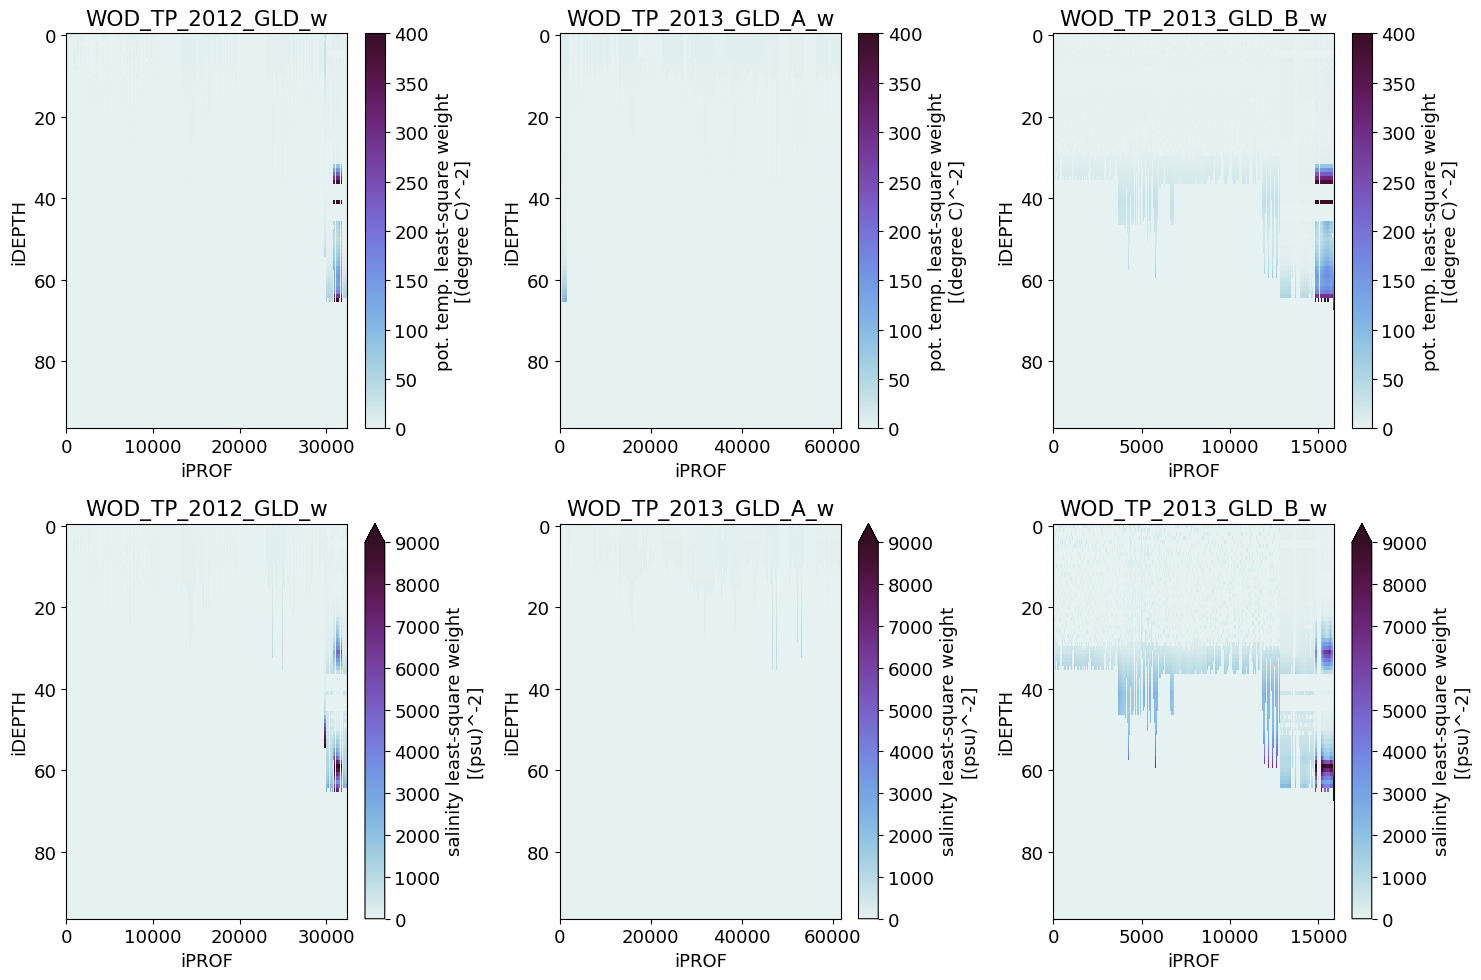

In [12]:
fig, ax = plt.subplots(figsize=(15,10),nrows=2,ncols=3)
ds2012.prof_Tweight.plot(x='iPROF',ax=ax[0,0],vmin=0,vmax=400,cmap=cmo.dense)
ax[0,0].invert_yaxis()
ax[0,0].set_title('WOD_TP_2012_GLD_w')
ds2013_A.prof_Tweight.plot(x='iPROF',ax=ax[0,1],vmin=0,vmax=400,cmap=cmo.dense)
ax[0,1].invert_yaxis()
ax[0,1].set_title('WOD_TP_2013_GLD_A_w')
ds2013_B.prof_Tweight.plot(x='iPROF',ax=ax[0,2],vmin=0,vmax=400,cmap=cmo.dense)
ax[0,2].invert_yaxis()
ax[0,2].set_title('WOD_TP_2013_GLD_B_w')

ds2012.prof_Sweight.plot(x='iPROF',ax=ax[1,0],vmin=0,vmax=9000,cmap=cmo.dense)
ax[1,0].invert_yaxis()
ax[1,0].set_title('WOD_TP_2012_GLD_w')
ds2013_A.prof_Sweight.plot(x='iPROF',ax=ax[1,1],vmin=0,vmax=9000,cmap=cmo.dense)
ax[1,1].invert_yaxis()
ax[1,1].set_title('WOD_TP_2013_GLD_A_w')
ds2013_B.prof_Sweight.plot(x='iPROF',ax=ax[1,2],vmin=0,vmax=9000,cmap=cmo.dense)
ax[1,2].invert_yaxis()
ax[1,2].set_title('WOD_TP_2013_GLD_B_w')
plt.tight_layout()
plt.savefig(foldername + 'glider_weight.png')